## Step 1: Load Data
Mounting Google Drive and loading the 5 Olist CSVs (orders, order items, products, payments, category translation).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'akanksha',
 'Screenshot_2025-12-11-13-59-20-38_944a2809ea1b4cda6ef12d1db9048ed3.jpg',
 "I am sharing 'MM ASSINGMENT PRINT' with you.pdf",
 'kalyani core resume 22je1037.pdf',
 'Doc Scanner',
 'Doc Scanner Upload',
 'DocScanner Feb 13, 2023 10-02 AM.pdf',
 'olist_data']

In [3]:
import os
os.listdir('/content/drive/MyDrive/olist_data')

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [5]:
import pandas as pd

path = '/content/drive/MyDrive/olist_data/'

orders = pd.read_csv(path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
category_translation = pd.read_csv(path + 'product_category_name_translation.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')

print(orders.shape, order_items.shape, products.shape)
orders.head()

(99441, 8) (112650, 7) (32951, 9)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Step 2: Merge & Clean
Joining order items, products, orders, and payments into a single table. Filtering to delivered orders only and trimming to the columns needed for pricing analysis.

In [6]:
# Step 1: order_items + products (to get category)
df = order_items.merge(products, on='product_id', how='left')

# Step 2: add English category names
df = df.merge(category_translation, on='product_category_name', how='left')

# Step 3: add order status and date
df = df.merge(orders[['order_id', 'order_status', 'order_purchase_timestamp']], on='order_id', how='left')

# Step 4: add payment info (installments as afford-ability proxy)
payments_agg = payments.groupby('order_id').agg({'payment_value': 'sum', 'payment_installments': 'max'}).reset_index()
df = df.merge(payments_agg, on='order_id', how='left')

print(df.shape)
df.head()

(112650, 20)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,order_status,order_purchase_timestamp,payment_value,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,delivered,2017-09-13 08:59:02,72.19,2.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,delivered,2017-04-26 10:53:06,259.83,3.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,delivered,2018-01-14 14:33:31,216.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,delivered,2018-08-08 10:00:35,25.78,2.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,delivered,2017-02-04 13:57:51,218.04,3.0


In [7]:
# Step 5: load and merge review scores (you haven't loaded this file yet)
order_reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
df = df.merge(order_reviews[['order_id', 'review_score']], on='order_id', how='left')

# Step 6: filter to delivered orders only
df = df[df['order_status'] == 'delivered']

# Step 7: trim to final clean columns
final_cols = ['order_id', 'product_id', 'product_category_name_english', 'price',
              'freight_value', 'payment_value', 'payment_installments',
              'order_purchase_timestamp', 'review_score']
df_clean = df[final_cols].copy()

print(df_clean.shape)
df_clean.head()

(110840, 9)


,order_id,product_id,product_category_name_english,price,freight_value,payment_value,payment_installments,order_purchase_timestamp,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.90,13.29,72.19,2.0,2017-09-13 08:59:02,5.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,239.90,19.93,259.83,3.0,2017-04-26 10:53:06,4.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,furniture_decor,199.00,17.87,216.87,5.0,2018-01-14 14:33:31,5.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumery,12.99,12.79,25.78,2.0,2018-08-08 10:00:35,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,garden_tools,199.90,18.14,218.04,3.0,2017-02-04 13:57:51,5.0


In [8]:
df_clean.isnull().sum()

,0
order_id,0
product_id,0
product_category_name_english,1567
price,0
freight_value,0
payment_value,3
payment_installments,3
order_purchase_timestamp,0
review_score,827


In [9]:
# Drop rows missing category name or payment info (small % of data, safe to drop)
df_clean = df_clean.dropna(subset=['product_category_name_english', 'payment_value', 'payment_installments'])

print(df_clean.shape)
df_clean.isnull().sum()

(109270, 9)


,0
order_id,0
product_id,0
product_category_name_english,0
price,0
freight_value,0
payment_value,0
payment_installments,0
order_purchase_timestamp,0
review_score,815


## Step 3: Price vs. Volume by Category
Aggregating average price, order volume, and revenue at the category level, then visualizing the relationship.

   product_category_name_english   avg_price  order_volume  total_revenue
7                 bed_bath_table   93.380543         11107     1037177.69
43                 health_beauty  130.023642          9516     1237304.98
65                sports_leisure  113.109800          8489      960189.09
39               furniture_decor   87.188346          8239      718344.78
15         computers_accessories  116.274427          7708      896243.28
49                    housewares   90.605181          6819      617836.73
70                 watches_gifts  198.883392          5869     1167246.63
68                     telephony   69.915226          4434      310004.11
42                  garden_tools  110.152095          4282      471671.27
5                           auto  139.553497          4158      580263.44


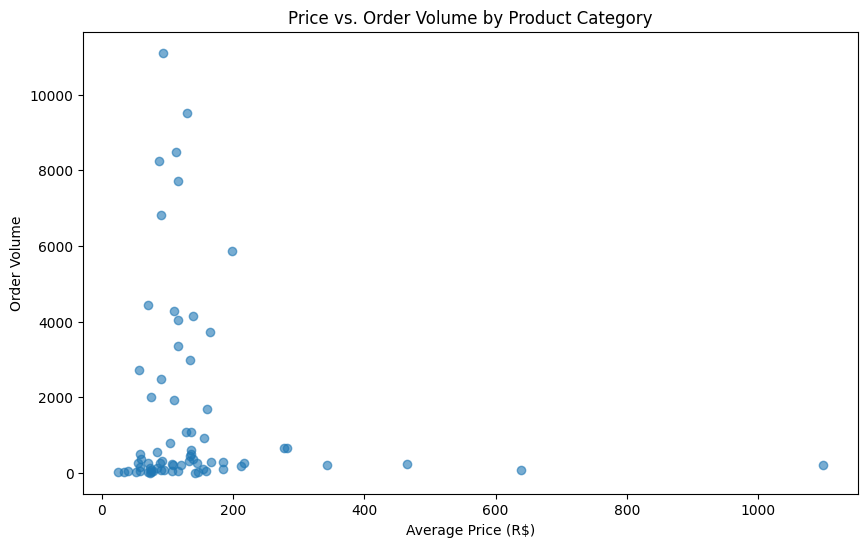

In [10]:
import matplotlib.pyplot as plt

# Group by category: avg price, order volume, revenue
category_stats = df_clean.groupby('product_category_name_english').agg(
    avg_price=('price', 'mean'),
    order_volume=('order_id', 'count'),
    total_revenue=('price', 'sum')
).reset_index()

category_stats = category_stats.sort_values('order_volume', ascending=False)
print(category_stats.head(10))

# Plot: price vs volume
plt.figure(figsize=(10,6))
plt.scatter(category_stats['avg_price'], category_stats['order_volume'], alpha=0.6)
plt.xlabel('Average Price (R$)')
plt.ylabel('Order Volume')
plt.title('Price vs. Order Volume by Product Category')
plt.show()

## Step 4: Quartile Analysis
Splitting categories into price quartiles to test whether the price-volume relationship is linear.

In [11]:
# Add price quartiles to segment categories
category_stats['price_quartile'] = pd.qcut(category_stats['avg_price'], 4, labels=['Q1_low', 'Q2', 'Q3', 'Q4_high'])

# Compare volume and revenue across quartiles
quartile_summary = category_stats.groupby('price_quartile').agg(
    avg_price=('avg_price', 'mean'),
    avg_volume=('order_volume', 'mean'),
    avg_revenue=('total_revenue', 'mean'),
    category_count=('product_category_name_english', 'count')
).reset_index()

print(quartile_summary)

  price_quartile   avg_price   avg_volume    avg_revenue  category_count
0         Q1_low   60.089947   618.166667   40739.430000              18
1             Q2   96.181478  2557.722222  249973.213333              18
2             Q3  130.706019  2154.529412  272377.051765              17
3        Q4_high  289.303949   859.833333  179988.055000              18


/tmp/ipykernel_15169/291299214.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartile_summary = category_stats.groupby('price_quartile').agg(


In [12]:
vol_ratio = quartile_summary.loc[1, 'avg_volume'] / quartile_summary.loc[3, 'avg_volume']
rev_ratio = quartile_summary.loc[1, 'avg_revenue'] / quartile_summary.loc[3, 'avg_revenue']
print(f"Q2 vs Q4 — Volume ratio: {vol_ratio:.2f}x, Revenue ratio: {rev_ratio:.2f}x")

Q2 vs Q4 — Volume ratio: 2.97x, Revenue ratio: 1.39x


## Step 5: Testing Price Elasticity
Attempting to estimate price elasticity of demand — first across categories, then within a single high-volume category over time.

**Note:** these regressions were not statistically significant (p > 0.28), likely due to category-identity and demand-period confounds rather than a true absence of price sensitivity. Kept here for transparency; see README for the fuller explanation.

In [13]:
import numpy as np
from scipy import stats

# log-log correlation across all categories (elasticity proxy)
log_price = np.log(category_stats['avg_price'])
log_volume = np.log(category_stats['order_volume'])

slope, intercept, r_value, p_value, std_err = stats.linregress(log_price, log_volume)
print(f"Elasticity coefficient: {slope:.3f}")
print(f"R-squared: {r_value**2:.3f}, p-value: {p_value:.4f}")

Elasticity coefficient: 0.408
R-squared: 0.017, p-value: 0.2855


In [14]:
df_clean['order_purchase_timestamp'] = pd.to_datetime(df_clean['order_purchase_timestamp'])
df_clean['month'] = df_clean['order_purchase_timestamp'].dt.to_period('M')

# pick a high-volume category to test
test_cat = 'bed_bath_table'
cat_df = df_clean[df_clean['product_category_name_english'] == test_cat]

monthly = cat_df.groupby('month').agg(
    avg_price=('price', 'mean'),
    volume=('order_id', 'count')
).reset_index()

monthly = monthly[monthly['volume'] > 5]  # drop sparse months
log_price = np.log(monthly['avg_price'])
log_volume = np.log(monthly['volume'])

slope, intercept, r_value, p_value, std_err = stats.linregress(log_price, log_volume)
print(f"{test_cat} — Elasticity: {slope:.3f}, R²: {r_value**2:.3f}, p-value: {p_value:.4f}")

bed_bath_table — Elasticity: 6.423, R²: 0.483, p-value: 0.0005


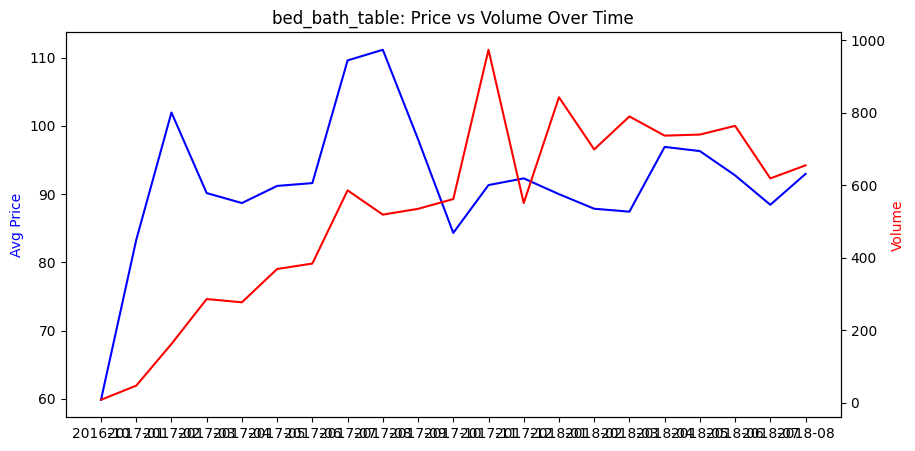

In [15]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(monthly['month'].astype(str), monthly['avg_price'], color='blue', label='Avg Price')
ax1.set_ylabel('Avg Price', color='blue')

ax2 = ax1.twinx()
ax2.plot(monthly['month'].astype(str), monthly['volume'], color='red', label='Volume')
ax2.set_ylabel('Volume', color='red')

plt.title(f'{test_cat}: Price vs Volume Over Time')
plt.xticks(rotation=45)
plt.show()

In [16]:
monthly = monthly.sort_values('month').reset_index(drop=True)
monthly['price_pct_change'] = monthly['avg_price'].pct_change()
monthly['volume_pct_change'] = monthly['volume'].pct_change()

monthly_clean = monthly.dropna(subset=['price_pct_change', 'volume_pct_change'])

slope, intercept, r_value, p_value, std_err = stats.linregress(
    monthly_clean['price_pct_change'], monthly_clean['volume_pct_change']
)
print(f"Detrended elasticity: {slope:.3f}, R²: {r_value**2:.3f}, p-value: {p_value:.4f}")

Detrended elasticity: 7.488, R²: 0.615, p-value: 0.0000


In [17]:
# Exclude early low-volume months (marketplace ramp-up period)
monthly_trimmed = monthly[monthly['volume'] >= 50].copy()  # adjust threshold as needed
monthly_trimmed = monthly_trimmed.sort_values('month').reset_index(drop=True)

monthly_trimmed['price_pct_change'] = monthly_trimmed['avg_price'].pct_change()
monthly_trimmed['volume_pct_change'] = monthly_trimmed['volume'].pct_change()
monthly_trimmed = monthly_trimmed.dropna()

slope, intercept, r_value, p_value, std_err = stats.linregress(
    monthly_trimmed['price_pct_change'], monthly_trimmed['volume_pct_change']
)
print(f"Trimmed detrended elasticity: {slope:.3f}, R²: {r_value**2:.3f}, p-value: {p_value:.4f}")

Trimmed detrended elasticity: 0.590, R²: 0.022, p-value: 0.5600


## Step 6: Segmentation — Mass-Market vs. Niche
Classifying categories into Mass-market, Niche, and Mixed segments based on price and volume, since the elasticity regressions above didn't yield a clean signal.

In [18]:
# Step 4: segment categories using price + affordability proxy
category_stats2 = df_clean.groupby('product_category_name_english').agg(
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean'),
    avg_installments=('payment_installments', 'mean'),
    order_volume=('order_id', 'count'),
    total_revenue=('price', 'sum')
).reset_index()

# classify into segments
median_price = category_stats2['avg_price'].median()
median_volume = category_stats2['order_volume'].median()

def segment(row):
    if row['avg_price'] <= median_price and row['order_volume'] >= median_volume:
        return 'Mass-market (low price, high volume)'
    elif row['avg_price'] > median_price and row['order_volume'] < median_volume:
        return 'Niche (high price, low volume)'
    else:
        return 'Mixed'

category_stats2['segment'] = category_stats2.apply(segment, axis=1)

print(category_stats2['segment'].value_counts())
category_stats2.sort_values('order_volume', ascending=False).head(15)

segment
Mixed                                   42
Mass-market (low price, high volume)    15
Niche (high price, low volume)          14
Name: count, dtype: int64


,product_category_name_english,avg_price,avg_freight,avg_installments,order_volume,total_revenue,segment
7,bed_bath_table,93.380543,18.394894,3.718646,11107,1037177.69,"Mass-market (low price, high volume)"
43,health_beauty,130.023642,18.896653,3.080496,9516,1237304.98,Mixed
65,sports_leisure,113.109800,19.371933,2.540464,8489,960189.09,"Mass-market (low price, high volume)"
39,furniture_decor,87.188346,20.635064,3.235830,8239,718344.78,"Mass-market (low price, high volume)"
15,computers_accessories,116.274427,18.820834,2.307473,7708,896243.28,Mixed
49,housewares,90.605181,21.002889,3.080657,6819,617836.73,"Mass-market (low price, high volume)"
70,watches_gifts,198.883392,16.750090,3.740842,5869,1167246.63,Mixed
68,telephony,69.915226,15.667747,2.354984,4434,310004.11,"Mass-market (low price, high volume)"
42,garden_tools,110.152095,22.630019,3.059085,4282,471671.27,"Mass-market (low price, high volume)"
5,auto,139.553497,21.826967,2.928571,4158,580263.44,Mixed


## Step 7: Key Finding
Comparing Mass-market vs. Niche segments directly — this produced the strongest, most defensible result in the analysis.

In [19]:
# Step 5: quantify the core finding — compare mass-market vs niche segments
segment_summary = category_stats2[category_stats2['segment'] != 'Mixed'].groupby('segment').agg(
    avg_price=('avg_price', 'mean'),
    avg_volume=('order_volume', 'mean'),
    avg_revenue=('total_revenue', 'mean'),
    avg_freight=('avg_freight', 'mean'),
    category_count=('product_category_name_english', 'count')
).reset_index()

print(segment_summary)

# calculate the ratio for your headline stat
mass = segment_summary[segment_summary['segment'].str.contains('Mass')].iloc[0]
niche = segment_summary[segment_summary['segment'].str.contains('Niche')].iloc[0]

price_ratio = niche['avg_price'] / mass['avg_price']
volume_ratio = mass['avg_volume'] / niche['avg_volume']
revenue_ratio = mass['avg_revenue'] / niche['avg_revenue']

print(f"\nNiche categories are priced {price_ratio:.1f}x higher than mass-market")
print(f"Mass-market categories move {volume_ratio:.1f}x more volume than niche")
print(f"Mass-market avg revenue per category is {revenue_ratio:.2f}x niche avg revenue per category")

                                segment   avg_price   avg_volume  \
0  Mass-market (low price, high volume)   86.160379  3666.800000   
1        Niche (high price, low volume)  295.772741   136.428571   

     avg_revenue  avg_freight  category_count  
0  337464.681333    18.068024              15  
1   46290.977857    29.258336              14  

Niche categories are priced 3.4x higher than mass-market
Mass-market categories move 26.9x more volume than niche
Mass-market avg revenue per category is 7.29x niche avg revenue per category
